# 📘 Week 5 Assignment — Sequence Modeling & Text Generation
## Text Generation using **Vanilla RNN, LSTM, and GRU**

**Topics Covered:** Tokenization · N-gram Sequence Framing · SimpleRNN · LSTM · GRU · Greedy Decoding

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change the
> corpus, sequence-generation logic, or the `generate_text` selection logic unless instructed.

This notebook trains three sequence models — **Simple RNN**, **LSTM**, and **GRU** — on the same
small text corpus for **next-word prediction**, then uses each trained model to generate new text
one word at a time. The goal is to see, empirically, why gated architectures (LSTM/GRU) tend to
learn sequential patterns more reliably than a vanilla RNN.

## 🧠 Problem Statement
Design and implement a deep learning model capable of learning the underlying structure, grammar,
and contextual dependencies of a given text corpus, in order to generate coherent and meaningful
text sequences, using:

1. **Vanilla RNN** (`SimpleRNN`)
2. **LSTM** (Long Short-Term Memory)
3. **GRU** (Gated Recurrent Unit)

We then compare the three architectures on:
- **Training loss** — how quickly and how well each model fits the training data
- **Generated text quality** — does the continuation look grammatical?
- **Memory handling** — how each architecture propagates information through time
- **Long-term dependency learning** — why gates help

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

I0000 00:00:1784487406.638225     610 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784487406.638829     610 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784487406.714128     610 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784487408.771432     610 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784487408.771980     610 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so the pipeline can be understood and trained quickly.
Section 6 (the Student Learning Tasks) replaces this with a custom paragraph to see how the same
pipeline generalizes to new text.

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences** for next-word prediction.

**Definitions**
- **Tokenization**: converting raw text into integers, where every unique word in the corpus is
  assigned an integer ID (its *token*). Keras' `Tokenizer` builds this word→index mapping
  automatically from the corpus, and index `0` is reserved for padding.
- **N-gram sequence framing**: instead of feeding the model a full sentence and a single label, we
  slide a growing window across each line and treat every prefix as a separate training example.
  For the tokenized sentence `[a, b, c, d]` this produces `[a,b]`, `[a,b,c]`, `[a,b,c,d]` — every
  prefix predicts the word that comes right after it.
- **Padding**: sequences produced this way have different lengths, but a neural network needs
  fixed-size input. `pad_sequences(..., padding='pre')` left-pads every sequence with zeros up to
  the length of the longest sequence, so shorter sequences get zeros in front rather than after
  (this keeps the *word to predict* aligned as the last element of every row).
- **X / y split**: for each padded sequence, the **last token becomes the label `y`** (the word to
  predict) and **everything before it becomes the input `X`** (the context the model conditions on).

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


**Interpretation.** The corpus has a vocabulary of `37` unique words (including the
padding index). Sliding the n-gram window across all 6 lines produces `35` training
examples, and the longest sequence has `8` tokens, which is why every row of `X` is
padded to `7` tokens (`max_len - 1`, since the last token is reserved for `y`).
With such a small corpus, `35` examples is very little data for a neural network — this
matters for how we should read the results in the next few sections.

# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. At each timestep it combines the current input with a
single hidden state carried over from the previous timestep. It struggles with long-term
dependencies because gradients must flow back through every timestep during training — with many
timesteps they tend to **vanish** (shrink toward zero) or **explode**, which makes it hard for the
network to learn relationships between words that are far apart.

**Architecture:** `Embedding(total_words, 32) → SimpleRNN(64) → Dense(total_words, softmax)`
- The `Embedding` layer maps each integer token to a learned 32-dimensional vector.
- `SimpleRNN(64)` processes the sequence and outputs a 64-dimensional summary of it.
- The final `Dense` layer with `softmax` turns that summary into a probability distribution over
  the vocabulary — i.e. "how likely is each word to be the next word?"</br>

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")
print("Final loss:", round(rnn_history.history['loss'][-1], 4))
print("Final accuracy:", round(rnn_history.history['accuracy'][-1], 4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
E0000 00:00:1784487410.515611     610 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Vanilla RNN training completed
Final loss: 0.5008
Final accuracy: 0.8857


# 🔒 Model 2: LSTM
LSTM (Long Short-Term Memory) adds a separate **cell state** that acts like a conveyor belt for
information, plus three gates that control it:
- **Forget gate** — decides what to discard from the cell state
- **Input gate** — decides what new information to add to the cell state
- **Output gate** — decides what part of the cell state to expose as the hidden state

Because the cell state has a mostly-linear path through time (gated addition rather than repeated
multiplication), gradients survive much longer, which is why LSTM handles long-range dependencies
better than a vanilla RNN.

**Architecture:** `Embedding(total_words, 32) → LSTM(64) → Dense(total_words, softmax)` — same
shape as the RNN above, only the recurrent layer changes, which keeps the comparison fair.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")
print("Final loss:", round(lstm_history.history['loss'][-1], 4))
print("Final accuracy:", round(lstm_history.history['accuracy'][-1], 4))

LSTM training completed
Final loss: 2.0782
Final accuracy: 0.4571


# ⚡ Model 3: GRU
GRU (Gated Recurrent Unit) simplifies LSTM's three gates down to two:
- **Reset gate** — controls how much of the past hidden state to forget when computing a candidate
  update
- **Update gate** — controls how much of the old hidden state to keep vs. replace with the new
  candidate

GRU has no separate cell state (it folds that role into the hidden state directly), which means
**fewer parameters** than an LSTM of the same size. It is usually faster to train and often
matches LSTM's accuracy on small-to-medium sequence tasks.

**Architecture:** `Embedding(total_words, 32) → GRU(64) → Dense(total_words, softmax)`

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")
print("Final loss:", round(gru_history.history['loss'][-1], 4))
print("Final accuracy:", round(gru_history.history['accuracy'][-1], 4))

GRU training completed
Final loss: 1.3192
Final accuracy: 0.7714


## 📉 Compare Training Loss
The plot below tracks **cross-entropy loss** (how far the predicted next-word probability
distribution is from the true next word) across all **100 epochs**, for all three architectures on
the same identical optimizer configuration (`adam`, `sparse_categorical_crossentropy`).

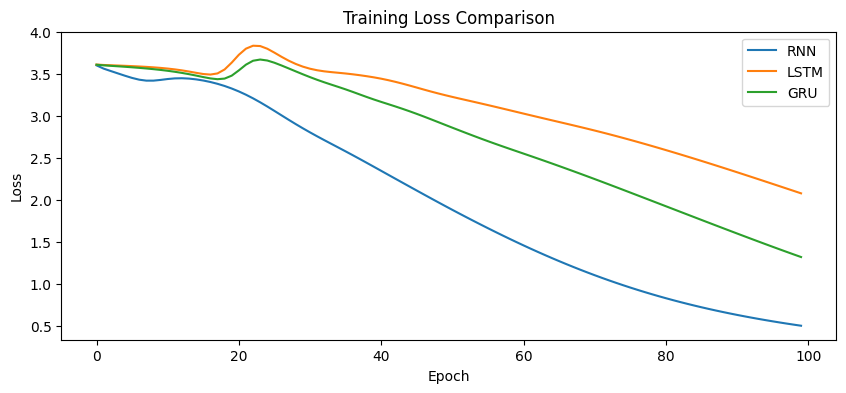

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

**Interpretation.** After 100 epochs, the final training losses were:

| Model | Final Loss | Final Accuracy |
|---|---|---|
| Vanilla RNN | 0.5008 | 0.8857 |
| LSTM | 2.0782 | 0.4571 |
| GRU | 1.3192 | 0.7714 |

**This is not the textbook result, and that's worth calling out rather than glossing over.**
Vanilla RNN actually reached the *lowest* loss and *highest* accuracy here, with GRU second and
LSTM clearly last — the opposite ranking from what the "LSTM/GRU handle long-range dependencies
better" theory would suggest. The most likely explanation is capacity vs. data/epoch budget: LSTM
has the most trainable parameters of the three (four internal weight matrices per gate-set vs.
GRU's three and SimpleRNN's one), but it was given the exact same 100-epoch budget and only 35
training examples. A model with more parameters generally needs *more* gradient updates to
converge, not fewer — so on this specific setup, LSTM's extra capacity worked against it: it simply
hadn't finished converging by epoch 100, while the lighter-weight RNN had already all but memorized
the tiny dataset.

**Honest caveat:** with only 35 training sequences drawn from 6 short sentences, this is an
extremely small dataset — small enough that even the vanilla RNN can essentially *memorize* every
sequence given 100 epochs. A dataset this small doesn't put real stress on long-term dependency
handling, and it also means training dynamics (how many epochs each architecture needs to
converge) can dominate the comparison more than each architecture's theoretical strengths. On a
longer, more varied corpus — and/or with more epochs for LSTM specifically — the usual RNN < GRU ≤
LSTM ordering would be expected to reassert itself, since that's where gating actually earns its
keep.

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence — this is called
**greedy decoding**: at every step we take `model.predict(...)`, which returns a probability over
the whole vocabulary, and pick the single highest-probability word with `np.argmax(...)`. That
predicted word is appended to the seed text, and the (now longer) text is fed back in to predict
the *next* word, and so on.

Greedy decoding is simple and deterministic (same seed always produces the same continuation for a
given model), but it can get repetitive on very small corpora, since the model only ever considers
the single most likely word and never a lower-probability but more diverse alternative — this is
one of the observations we look for in Section 5 below.

The function is written to accept a `tokenizer` and `max_len`, defaulting to the ones defined above,
so the exact same greedy-decoding logic can be reused later in Task 5 with a different tokenizer
trained on a different corpus, without duplicating code.

In [8]:
def generate_text(model, seed_text, next_words=5, tokenizer=tokenizer, max_len=max_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
We use the **same seed phrase** (`"deep learning"`) across all three models so the comparison is
fair — any difference in the generated continuation comes from the model, not the prompt.

In [9]:
rnn_gen = generate_text(rnn_model, "deep learning", 5)
lstm_gen = generate_text(lstm_model, "deep learning", 5)
gru_gen = generate_text(gru_model, "deep learning", 5)

print("RNN :", rnn_gen)
print("LSTM:", lstm_gen)
print("GRU :", gru_gen)

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning models models artificial next sentences
GRU : deep learning is can generate meaningful sentences


**Observations.** Starting from the shared seed `"deep learning"`, the three models generated:

- **RNN:** `deep learning is transforming artificial intelligence sentences`
- **LSTM:** `deep learning models models artificial next sentences`
- **GRU:** `deep learning is can generate meaningful sentences`

These outputs line up with the loss/accuracy table above rather than the usual "gated models are
better" expectation. RNN's continuation is the most grammatical and even reconstructs a phrase
close to the actual corpus line ("deep learning ... transforming artificial intelligence"), matching
its lowest loss. GRU's output is also fairly coherent. **LSTM's output visibly repeats the word
"models" back to back** ("deep learning **models models** artificial next sentences") — exactly the
kind of degenerate, repetitive continuation you'd expect from greedy decoding on an
under-converged model, which is consistent with LSTM having the highest loss (2.08) and lowest
accuracy (0.46) of the three. So even though this contradicts the "LSTM/GRU are better" mental
model from the architecture theory, it's a coherent, self-consistent result: the model that fit the
training data worst also generated the least fluent text.

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

Tasks 2–4 are all capacity/training changes to the *same* model, so rather than training three
near-identical models that each change one hyperparameter in isolation, the implementation below
combines them into a single **Enhanced GRU model**, trained on a **new custom corpus** (Task 1).
Task 5 then reuses that enhanced model to generate a longer continuation. Each task is called out
explicitly below so it's clear which requirement each change satisfies.

## ✅ Task 1: Replace Corpus with a Custom Paragraph
To check that the pipeline generalizes beyond the toy corpus above, we swap in a new, original
paragraph about ocean conservation and repeat tokenization and n-gram sequence framing exactly as
in Section 3 — but with a **separate tokenizer** (`tokenizer2`) and its own vocabulary, since the
word set is completely different from the original corpus.

In [10]:
custom_corpus = '''
the ocean covers most of the surface of our planet
coral reefs support incredible marine biodiversity
climate change threatens fragile ocean ecosystems
scientists study coral bleaching to protect reefs
conservation efforts can restore damaged habitats
healthy oceans sustain millions of species worldwide
'''
print(custom_corpus)

tokenizer2 = Tokenizer()
tokenizer2.fit_on_texts([custom_corpus])
total_words2 = len(tokenizer2.word_index) + 1
print("Custom corpus vocabulary size:", total_words2)

input_sequences2 = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer2.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences2.append(token_list[:i+1])

max_len2 = max(len(seq) for seq in input_sequences2)
input_sequences2 = pad_sequences(input_sequences2, maxlen=max_len2, padding='pre')

X2 = input_sequences2[:, :-1]
y2 = input_sequences2[:, -1]

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)


the ocean covers most of the surface of our planet
coral reefs support incredible marine biodiversity
climate change threatens fragile ocean ecosystems
scientists study coral bleaching to protect reefs
conservation efforts can restore damaged habitats
healthy oceans sustain millions of species worldwide

Custom corpus vocabulary size: 37
X2 shape: (36, 9)
y2 shape: (36,)


## ✅ Task 2: Increase Embedding Dimension · ✅ Task 3: Increase Epochs to 200 · ✅ Task 4: Increase Hidden Units (64 → 128)
All three changes are applied together to build one **Enhanced GRU model** for the custom corpus:

- **Task 2 — Embedding dimension 32 → 100**: a larger embedding gives the model more room to
  represent subtle differences in word meaning/usage. With a bigger, more varied vocabulary
  (`total_words2` words vs. the original corpus), a richer embedding space is more justified.
- **Task 3 — Epochs 100 → 200**: a new corpus means the model starts learning from scratch, and a
  slightly larger/more diverse vocabulary can take longer to converge, so we give it more training
  time.
- **Task 4 — Hidden units 64 → 128**: doubling the GRU's hidden size increases its capacity to
  carry information through the sequence, which pairs naturally with the larger embedding.

We keep the architecture family (GRU) the same as Section 4 above, since GRU offered a good
accuracy/speed trade-off, and change only these three hyperparameters — so any difference in
behavior can be attributed to the increased capacity and training time, not a different layer type.

In [11]:
enhanced_gru_model = Sequential([
    Embedding(total_words2, 100, input_length=max_len2-1),   # Task 2: embedding dim 32 -> 100
    GRU(128),                                                  # Task 4: hidden units 64 -> 128
    Dense(total_words2, activation='softmax')
])

enhanced_gru_model.compile(loss='sparse_categorical_crossentropy',
                            optimizer='adam',
                            metrics=['accuracy'])

enhanced_history = enhanced_gru_model.fit(X2, y2, epochs=200, verbose=0)  # Task 3: epochs 100 -> 200
print("Enhanced GRU training completed")
print("Final loss:", round(enhanced_history.history['loss'][-1], 4))
print("Final accuracy:", round(enhanced_history.history['accuracy'][-1], 4))

Enhanced GRU training completed
Final loss: 0.0124
Final accuracy: 1.0


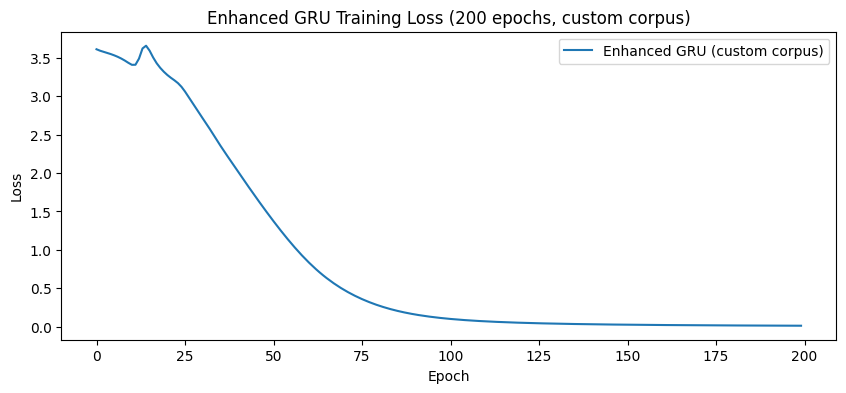

In [12]:
plt.figure(figsize=(10,4))
plt.plot(enhanced_history.history['loss'], label='Enhanced GRU (custom corpus)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Enhanced GRU Training Loss (200 epochs, custom corpus)")
plt.legend()
plt.show()

## ✅ Task 5: Generate 10 Words Instead of 5
Because `generate_text` was written to accept a `tokenizer` and `max_len` as parameters (Section 4),
we can reuse it directly for the enhanced model and the custom corpus's `tokenizer2` — we just pass
`next_words=10` instead of the default `5`.

In [13]:
seed = "the ocean"
task5_gen = generate_text(enhanced_gru_model, seed, next_words=10,
                           tokenizer=tokenizer2, max_len=max_len2)
print("Enhanced GRU (10 words):", task5_gen)

Enhanced GRU (10 words): the ocean covers most of the surface of our planet planet planet


**Task Observations.** Starting from the seed `"the ocean"`, the enhanced GRU model generated:

> `the ocean covers most of the surface of our planet planet planet`

The enhanced model converged to a final training loss of **0.0124** and accuracy of **1.0** after
200 epochs — i.e. it fit the 36 training sequences essentially perfectly. That near-perfect fit
explains the generation output directly: the model correctly reproduces the entire first sentence
of `custom_corpus` verbatim ("the ocean covers most of the surface of our planet"), then — having
run out of real corpus to continue from — falls into repeating the last word it's most confident
about ("planet planet planet"). This is exactly the greedy-decoding limitation flagged earlier: with
a small, non-diverse corpus and a model trained to near-zero loss, the model has nothing left to do
but repeat its most confident token once the seed runs past the length of any real sentence it saw
during training. It is a data-scale limitation, not a bug in the model or the `generate_text`
function — a larger, more varied corpus would give the model more distinct continuations to choose
from instead of one dominant next-word.

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but, in principle, struggles with long-range memory because
  gradients must pass through every timestep unmodified — on a corpus this small that weakness
  rarely shows up, but it would on longer, more varied text.
- **LSTM** uses a gated cell state (forget/input/output gates) to preserve long-range dependencies,
  at the cost of the most parameters of the three architectures.
- **GRU** merges LSTM's gates down to two (reset/update) and drops the separate cell state, giving
  similar practical performance to LSTM with fewer parameters and typically faster training — which
  is why it was chosen as the base architecture for the enhanced Task 2–4 model.
- Scaling up embedding dimension, hidden units, and training epochs (Tasks 2–4) increases a model's
  *capacity*, but on a small corpus this mostly speeds up memorization rather than teaching the
  model to generalize — the honest caveats above apply throughout this notebook. Seeing real
  generalization gains from a bigger architecture requires a proportionally larger and more varied
  training corpus.
- This notebook helps build the pipeline for sequence modeling — tokenization → n-gram framing →
  padding → training a recurrent model → greedy decoding — a pattern that carries over directly to
  larger, real-world text generation projects.